In [7]:
# Hemora_Thalassemia_Hybrid_ResNet_EfficientNet.ipynb #

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive
from google.colab import files
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

# ==========================================
# 1. SETUP & DRIVE MOUNT
# ==========================================
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

# Update these paths to your saved .keras or .h5 models
RESNET_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/ResNet50 Model/best_thalassemia_res_model.keras'
EFFNET_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/EfficientNet Model/best_efficientnet_model.keras'
RESULTS_DIR = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/Hybrid_Model'

if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)


Step 1: Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ==========================================
# 2. LOAD MODELS (ENSEMBLE FUSION)
# ==========================================
print("\nStep 2: Loading Ensemble Components...")

try:
    resnet_model = load_model(RESNET_PATH)
    print("✅ ResNet50V2 Model Loaded.")

    effnet_model = load_model(EFFNET_PATH)
    print("✅ EfficientNetB0 Model Loaded.")
except Exception as e:
    print(f"❌ Error loading models: {e}")
    print("Please verify the file paths in your Google Drive.")



Step 2: Loading Ensemble Components...
✅ ResNet50V2 Model Loaded.
✅ EfficientNetB0 Model Loaded.



Upload a Blood Smear Image for Hybrid Ensemble Analysis:


Saving B9780702031472000018_f001-001b-9780702031472.jpg to B9780702031472000018_f001-001b-9780702031472.jpg

Processing Full Smear: B9780702031472000018_f001-001b-9780702031472.jpg...
Analyzing 130 potential cells using Ensemble Consensus...


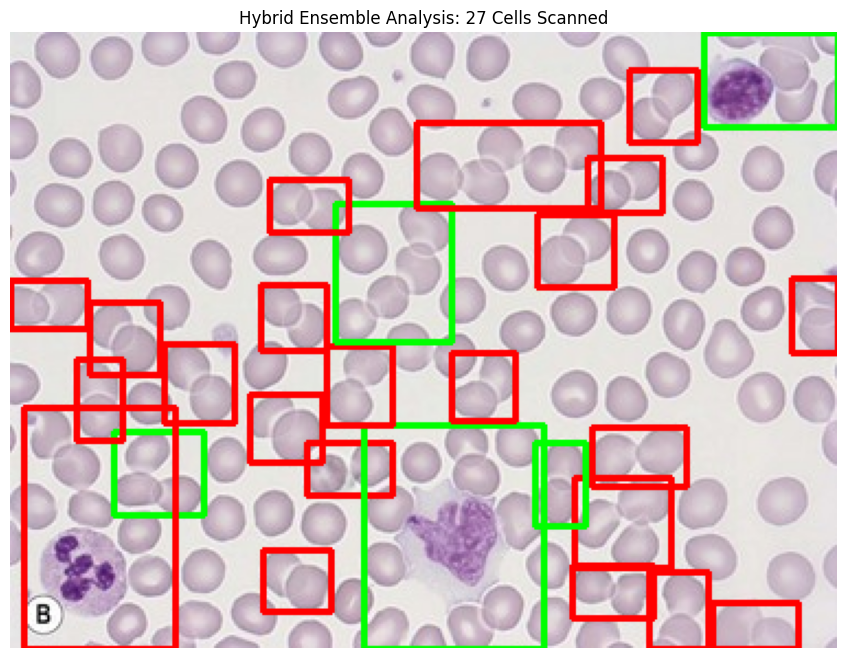

BETA-THALASSEMIA (MINOR) HYBRID ENSEMBLE REPORT
Total Cells Scanned:    27
Normal RBCs (Green):    5
Abnormal RBCs (Red):    22
Morphological Abnormality Ratio: 81.48%

>>> RESULT: POSITIVE indicators for Thalassemia Minor.
>>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).


In [21]:

# ==========================================
# 3. HYBRID ENSEMBLE PIPELINE
# ==========================================

# OPTIMIZATION: High-Confidence Consensus Threshold
# A cell must be confirmed by both models to be flagged
HYBRID_THRESHOLD = 0.75

def preprocess_cell(cell_crop):
    """Resizes and normalizes cell for both models"""
    cell_rgb = cv2.cvtColor(cell_crop, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(cell_rgb, (224, 224))
    img_array = img_to_array(resized) / 255.0
    return np.expand_dims(img_array, axis=0)

def run_hybrid_ensemble(image_path):
    print(f"\nProcessing Full Smear: {image_path}...")
    original_img = cv2.imread(image_path)
    if original_img is None: return
    output_img = original_img.copy()

    # Segmentation Logic (Finding individual RBCs)
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    thal_count = 0
    total_cells = 0

    print(f"Analyzing {len(contours)} potential cells using Ensemble Consensus...")

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if cv2.contourArea(cnt) < 500 or cv2.contourArea(cnt) > 6500: continue

        cell_crop = original_img[y:y+h, x:x+w]
        if cell_crop.size == 0: continue
        total_cells += 1

        # Preprocess cell once for both models
        processed_input = preprocess_cell(cell_crop)

        # Get predictions from both models
        res_score = resnet_model.predict(processed_input, verbose=0)[0][0]
        eff_score = effnet_model.model.predict(processed_input, verbose=0)[0][0] if hasattr(effnet_model, 'model') else effnet_model.predict(processed_input, verbose=0)[0][0]

        # ENSEMBLE LOGIC: Average probability for final decision
        # This reduces False Positives by requiring high confidence from both architectures
        hybrid_consensus = (res_score + eff_score) / 2

        if hybrid_consensus > HYBRID_THRESHOLD:
            color = (0, 0, 255) # Red for Thalassemia features
            thal_count += 1
        else:
            color = (0, 255, 0) # Green for Normal morphology

        cv2.rectangle(output_img, (x, y), (x + w, y + h), color, 2)

    # Display Result
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Hybrid Ensemble Analysis: {total_cells} Cells Scanned")
    plt.show()

    # Clinical Reporting
    print("="*50)
    print("BETA-THALASSEMIA (MINOR) HYBRID ENSEMBLE REPORT")
    print("="*50)
    print(f"Total Cells Scanned:    {total_cells}")
    print(f"Normal RBCs (Green):    {total_cells - thal_count}")
    print(f"Abnormal RBCs (Red):    {thal_count}")

    if total_cells > 0:
        ratio = (thal_count / total_cells) * 100
        print(f"Morphological Abnormality Ratio: {ratio:.2f}%")

        if ratio > 5.0:
            print("\n>>> RESULT: POSITIVE indicators for Thalassemia Minor.")
            print(">>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).")
        else:
            print("\n>>> RESULT: NEGATIVE - Healthy Smear.")
    print("="*50)

# --- EXECUTE ---
print("\nUpload a Blood Smear Image for Hybrid Ensemble Analysis:")
uploaded = files.upload()
if uploaded:
    fname = list(uploaded.keys())[0]
    run_hybrid_ensemble(fname)